In [1]:
import os
NUM_THREADS = "8"
os.environ["OMP_NUM_THREADS"] = NUM_THREADS 
os.environ["OPENBLAS_NUM_THREADS"] = NUM_THREADS
os.environ["MKL_NUM_THREADS"] = NUM_THREADS
os.environ["VECLIB_MAXIMUM_THREADS"] = NUM_THREADS
os.environ["NUMEXPR_NUM_THREADS"] = NUM_THREADS

In [2]:
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def compile_run_program(compile_cmd, run_cmd):
    program_output = ""
    compile_process = subprocess.run(compile_cmd, capture_output=True, text=True)

    if compile_process.returncode == 0:        
        # Run the compiled program
        run_process = subprocess.run(run_cmd, capture_output=True, text=True)
        program_output = run_process.stdout
    else:
        print("Compilation failed.")
        print("Compiler output:")
        print(compile_process.stderr)
    return program_output

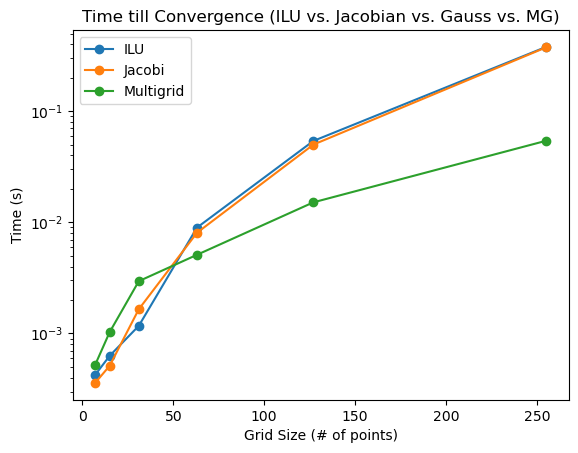

In [5]:
# Define relative paths
SRC_DIR = ".."
PROGRAM = "pcg.c"
OUTPUT = "pcg.exe"
IMG_OUTPUT = "../images"
IMG = "pcg_preconditioner_time.png"


FLAG_TIME="-time"

pattern = re.compile(r"(\d+\.\d+) seconds")
compile_command = ["gcc", "-g2", "-lm", "-fopenmp", "-I../src_pcg", 
                   os.path.join(SRC_DIR, PROGRAM), "-o", os.path.join(SRC_DIR, OUTPUT)]

GRIDSIZES = [str(2**x - 1) for x in range(3,9)]

# Preconditioner Options:
#   1: ILU(0)
#   2: Jacobi
#   3: Gauß-Seidel
#   4: Multigrid
PRECONDITIONERS = {"1" : "ILU", 
                   "2" : "Jacobi",
                   "4" : "Multigrid",
                #    "3" : "Gauss-Seidel",
                  }

iteration_counts = np.zeros((len(PRECONDITIONERS),len(GRIDSIZES)))

for i, PRECON in enumerate(PRECONDITIONERS.keys()):
    for j, GRIDSIZE in enumerate(GRIDSIZES):
        run_command = [os.path.join(SRC_DIR, OUTPUT), GRIDSIZE, PRECON, FLAG_TIME]
        program_output = compile_run_program(compile_command, run_command)
        # print(program_output)
        match = re.search(pattern, program_output)

        if match:
            iteration_counts[i,j] = float(match.group(1))
        else:
            iteration_counts[i,j] = -1

    plt.plot([int(i) for i in GRIDSIZES], iteration_counts[i,:], label=PRECONDITIONERS[PRECON], marker='o')

plt.yscale('log')
plt.xlabel('Grid Size (# of points)')
plt.ylabel('Time (s)')
plt.title('Time till Convergence (ILU vs. Jacobian vs. Gauss vs. MG)')
plt.legend()


os.makedirs(IMG_OUTPUT, exist_ok=True)
output_file = os.path.join(IMG_OUTPUT, IMG)
plt.savefig(output_file)

plt.show()